<a href="https://colab.research.google.com/github/marti4283/An-lisis_Violencia_Intrafamiliar_Colombia/blob/main/An%C3%A1lisis_Violencia_Intrafamiliar_Colombia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EXTRACCION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Reporte_Delito_Violencia_Intrafamiliar_Polic_a_Nacional.csv', low_memory=False)

In [3]:
df.head(50)

,DEPARTAMENTO,MUNICIPIO,CODIGO DANE,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD
0,ATLÁNTICO,BARRANQUILLA (CT),8001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
1,BOYACÁ,DUITAMA,15238000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
2,CAQUETÁ,PUERTO RICO,18592000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
3,CASANARE,MANÍ,85139000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
4,CUNDINAMARCA,BOGOTÁ D.C. (CT),11001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
5,SUCRE,SINCELEJO (CT),70001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
6,VALLE,CALI (CT),76001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,2
7,VALLE,CALI (CT),76001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,2
8,VALLE,TULUÁ,76834000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
9,HUILA,PITALITO,41551000,ARMA DE FUEGO,1/01/2010,FEMENINO,ADULTOS,1


##TRANSFORMACION

1. Verificación

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476970 entries, 0 to 476969
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DEPARTAMENTO  476970 non-null  object
 1   MUNICIPIO     476970 non-null  object
 2   CODIGO DANE   476970 non-null  object
 3   ARMAS MEDIOS  476968 non-null  object
 4   FECHA HECHO   476970 non-null  object
 5   GENERO        476967 non-null  object
 6   GRUPO ETARIO  475355 non-null  object
 7   CANTIDAD      476970 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 29.1+ MB


2. Verificación de valores nulos

In [5]:
df.isnull().sum()

,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,2
FECHA HECHO,0
GENERO,3
GRUPO ETARIO,1615
CANTIDAD,0


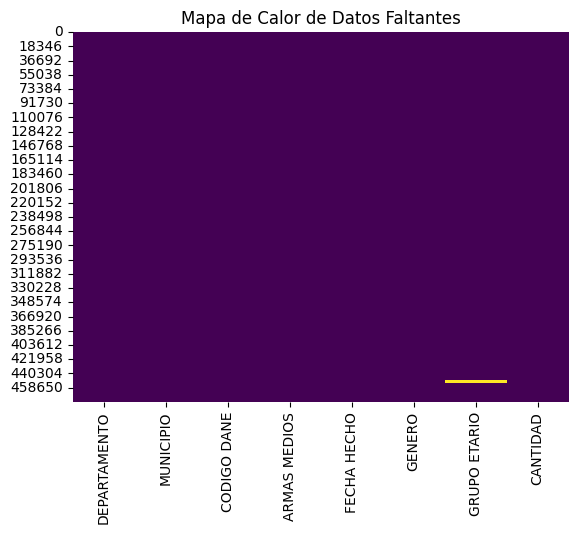

In [6]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes')
plt.show()

3. Copia a dataframe

In [7]:
df_clean = df.copy()
display(df_clean.head())

,DEPARTAMENTO,MUNICIPIO,CODIGO DANE,ARMAS MEDIOS,FECHA HECHO,GENERO,GRUPO ETARIO,CANTIDAD
0,ATLÁNTICO,BARRANQUILLA (CT),8001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
1,BOYACÁ,DUITAMA,15238000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
2,CAQUETÁ,PUERTO RICO,18592000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,MASCULINO,ADULTOS,1
3,CASANARE,MANÍ,85139000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1
4,CUNDINAMARCA,BOGOTÁ D.C. (CT),11001000,ARMA BLANCA / CORTOPUNZANTE,1/01/2010,FEMENINO,ADULTOS,1


4. Tranformación de columna FECHA HECHO a datetime

In [8]:
#Tranformar la columna FECHA HECHO a datatime
df_clean['FECHA HECHO'] = pd.to_datetime(df['FECHA HECHO'], format='%d/%m/%Y', errors='coerce')
print(df_clean['FECHA HECHO'].dtype)

datetime64[ns]


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476970 entries, 0 to 476969
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DEPARTAMENTO  476970 non-null  object        
 1   MUNICIPIO     476970 non-null  object        
 2   CODIGO DANE   476970 non-null  object        
 3   ARMAS MEDIOS  476968 non-null  object        
 4   FECHA HECHO   476962 non-null  datetime64[ns]
 5   GENERO        476967 non-null  object        
 6   GRUPO ETARIO  475355 non-null  object        
 7   CANTIDAD      476970 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 29.1+ MB


5. Verificación y transformación de nulos

In [10]:
df_clean.isnull().sum()

,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,2
FECHA HECHO,8
GENERO,3
GRUPO ETARIO,1615
CANTIDAD,0


In [11]:
# El siguiente codigo busca todos los valores nulos (NaN o None) en la columna 'GRUPO ETARIO'
# y los reemplaza por la cadena de texto 'Desconocido'.
df_clean['GRUPO ETARIO'] = df_clean['GRUPO ETARIO'].fillna('Desconocido')
print(df_clean['GRUPO ETARIO'].isnull().sum())

0


In [12]:
df_clean.isnull().sum()

,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,2
FECHA HECHO,8
GENERO,3
GRUPO ETARIO,0
CANTIDAD,0


In [13]:
# Eliminación de filas con valores nulos en 'FECHA HECHO', 'GENERO' y 'ARMAS MEDIOS'
df_clean.dropna(subset=['FECHA HECHO', 'GENERO', 'ARMAS MEDIOS'], inplace=True)

# Verificar de nuevo los valores nulos
print("Conteo de valores nulos después de la eliminación:")
display(df_clean.isnull().sum())

Conteo de valores nulos después de la eliminación:


,0
DEPARTAMENTO,0
MUNICIPIO,0
CODIGO DANE,0
ARMAS MEDIOS,0
FECHA HECHO,0
GENERO,0
GRUPO ETARIO,0
CANTIDAD,0


## Análisis exploratorio de datos (EDA)

1. Analisis distribución de las diferentes columnas.

In [14]:
print("Distribución de ARMAS MEDIOS:")
display(df_clean['ARMAS MEDIOS'].value_counts())

Distribución de ARMAS MEDIOS:


,count
ARMAS MEDIOS,
CONTUNDENTES,244945
SIN EMPLEO DE ARMAS,108776
NO REPORTADO,71921
ARMA BLANCA / CORTOPUNZANTE,38070
NO REPORTA,4421
ESCOPOLAMINA,3863
ARMA DE FUEGO,2323
CORTOPUNZANTES,1167
CORTANTES,1138


In [15]:
print("Distribución de GRUPO ETARIO:")
display(df_clean['GRUPO ETARIO'].value_counts())

Distribución de GRUPO ETARIO:


,count
GRUPO ETARIO,
ADULTOS,420230
ADOLESCENTES,28396
MENORES,26447
Desconocido,1612
NO REPORTA,274


In [16]:
print("Distribución de MUNICIPIO (Top 10):")
display(df_clean['MUNICIPIO'].value_counts().head(10))

Distribución de MUNICIPIO (Top 10):


,count
MUNICIPIO,
BOGOTÁ D.C. (CT),53791
MEDELLÍN (CT),22032
CALI (CT),18958
BUCARAMANGA (CT),10420
VILLAVICENCIO (CT),9675
BARRANQUILLA (CT),8800
PASTO (CT),8550
CARTAGENA (CT),8408
CÚCUTA (CT),8202


In [17]:
print("Distribución de GENERO:")
display(df_clean['GENERO'].value_counts())

Distribución de GENERO:


,count
GENERO,
FEMENINO,366900
MASCULINO,109758
NO REPORTA,294
-,7


In [18]:
print("Distribución de DEPARTAMENTO:")
display(df_clean['DEPARTAMENTO'].value_counts())

Distribución de DEPARTAMENTO:


,count
DEPARTAMENTO,
CUNDINAMARCA,88097
ANTIOQUIA,57288
VALLE,44908
SANTANDER,38493
BOYACÁ,26920
ATLÁNTICO,17516
TOLIMA,17007
HUILA,16547
META,16223


2. Graficos distribución de las diferentes columnas.

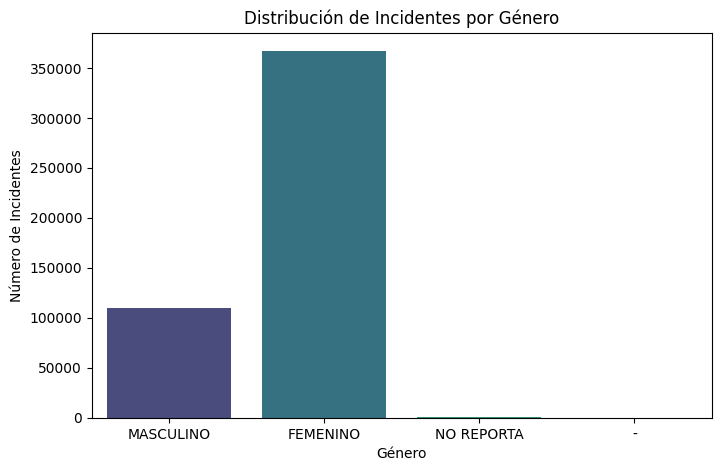

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='GENERO', hue='GENERO', palette='viridis', legend=False)
plt.title('Distribución de Incidentes por Género')
plt.xlabel('Género')
plt.ylabel('Número de Incidentes')
plt.show()

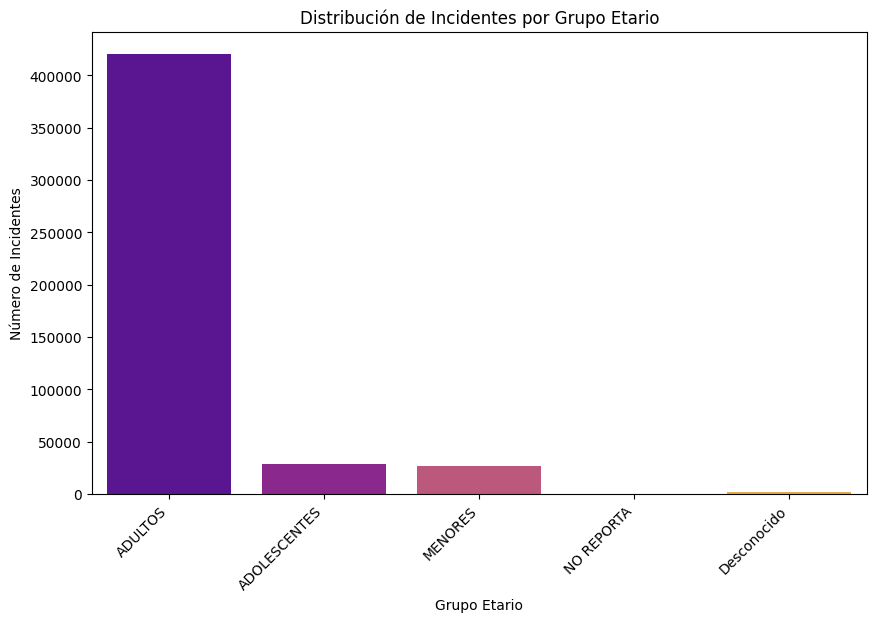

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='GRUPO ETARIO', hue='GRUPO ETARIO', palette='plasma', legend=False)
plt.title('Distribución de Incidentes por Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

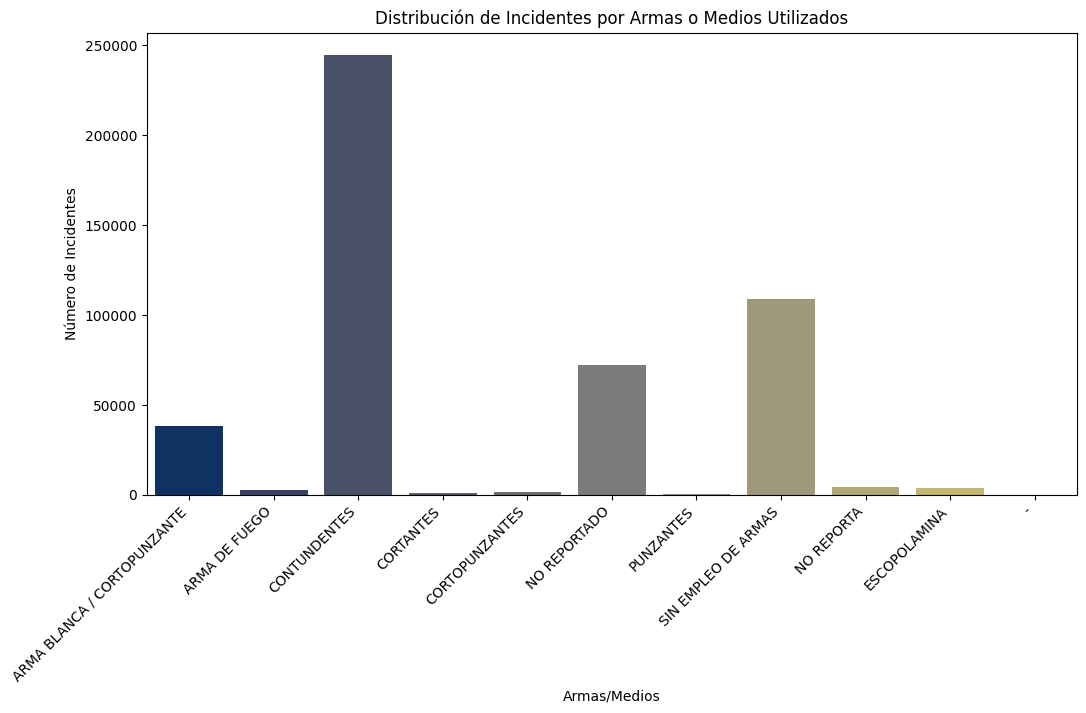

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='ARMAS MEDIOS', hue='ARMAS MEDIOS', palette='cividis', legend=False)
plt.title('Distribución de Incidentes por Armas o Medios Utilizados')
plt.xlabel('Armas/Medios')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.show()

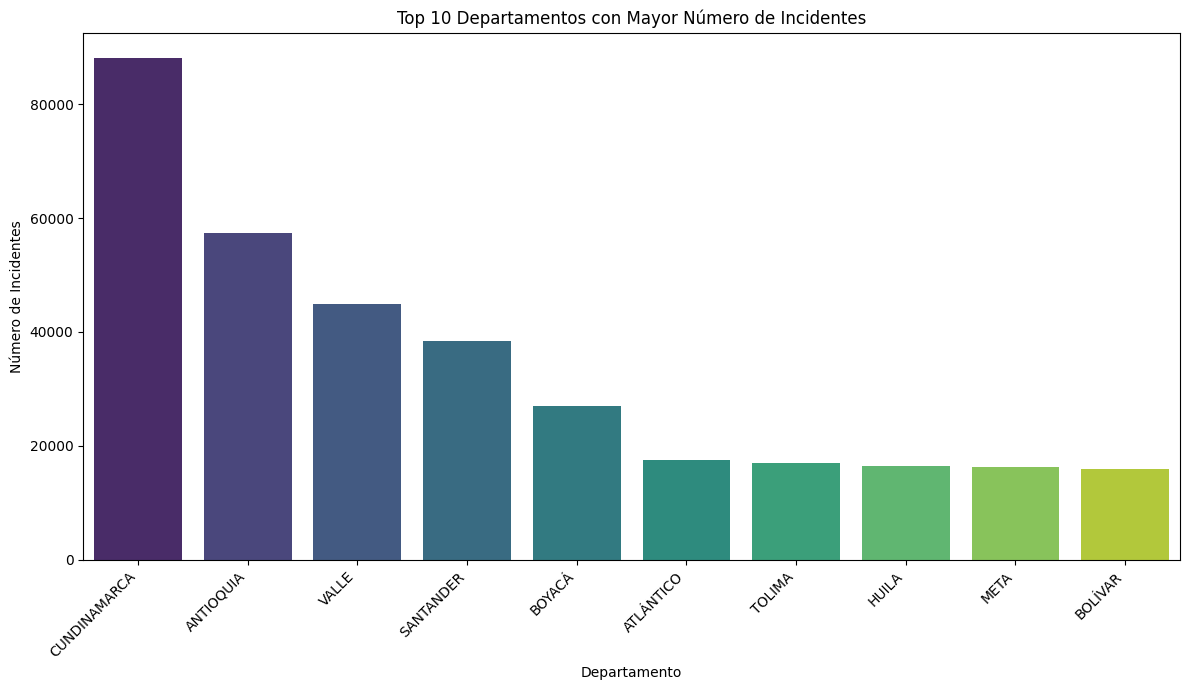

In [22]:
# Agrupar por Departamento y contar incidentes, mostrando los top 10
incidentes_por_departamento = df_clean['DEPARTAMENTO'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=incidentes_por_departamento.index, y=incidentes_por_departamento.values, hue=incidentes_por_departamento.index, palette='viridis', legend=False)
plt.title('Top 10 Departamentos con Mayor Número de Incidentes')
plt.xlabel('Departamento')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

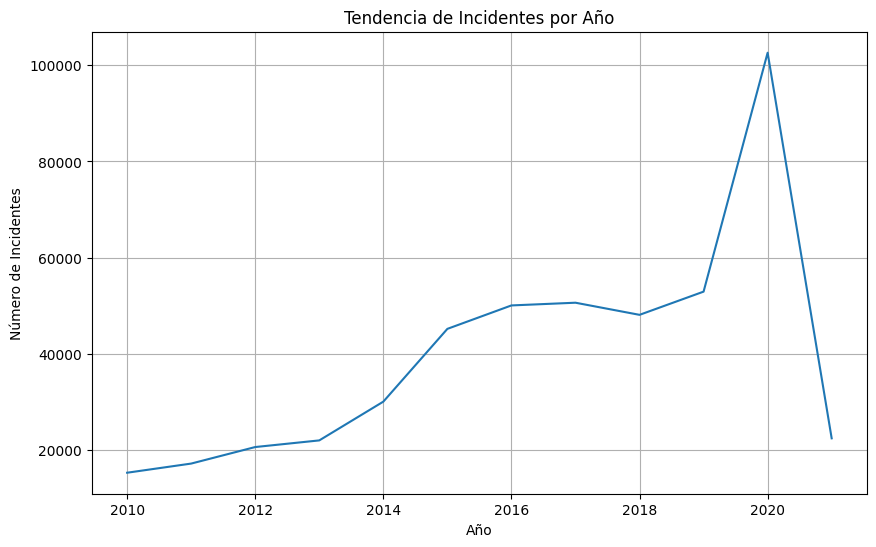

In [23]:
# Se extrae el año y el mes de la columna FECHA HECHO
df_clean['YEAR'] = df_clean['FECHA HECHO'].dt.year
df_clean['MONTH'] = df_clean['FECHA HECHO'].dt.month

# Se agrupa por año y contar incidentes
incidentes_anualmente = df_clean['YEAR'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=incidentes_anualmente.index, y=incidentes_anualmente.values)
plt.title('Tendencia de Incidentes por Año')
plt.xlabel('Año')
plt.ylabel('Número de Incidentes')
plt.grid(True)
plt.show()

In [24]:
incidentes_genero_edad = df_clean.groupby(['GRUPO ETARIO', 'GENERO']).size().unstack(fill_value=0)
display(incidentes_genero_edad.head())

GENERO,-,FEMENINO,MASCULINO,NO REPORTA
GRUPO ETARIO,,,,
ADOLESCENTES,0,19991,8405,0
ADULTOS,0,333224,86988,18
Desconocido,7,1002,603,0
MENORES,0,12683,13762,2
NO REPORTA,0,0,0,274


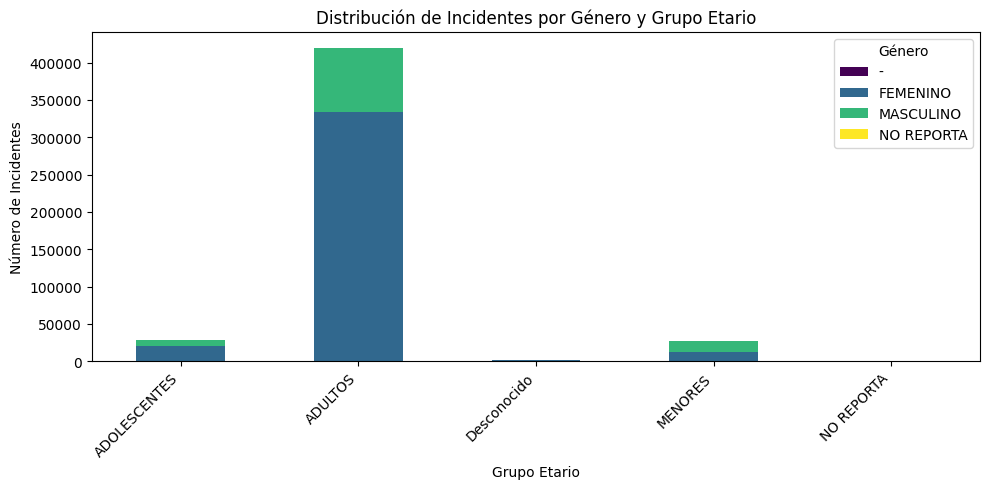

In [25]:
incidentes_genero_edad.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')
plt.title('Distribución de Incidentes por Género y Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

In [26]:
top_10_departamentos = incidentes_por_departamento.index
df_top_10_departmentos = df_clean[df_clean['DEPARTAMENTO'].isin(top_10_departamentos)]

incidentes_departmento_genero = df_top_10_departmentos.groupby(['DEPARTAMENTO', 'GENERO']).size().unstack(fill_value=0)
display(incidentes_departmento_genero.head())

GENERO,-,FEMENINO,MASCULINO,NO REPORTA
DEPARTAMENTO,,,,
ANTIOQUIA,0,43910,13356,22
ATLÁNTICO,0,13441,4071,4
BOLÍVAR,0,12181,3755,18
BOYACÁ,1,21678,5225,16
CUNDINAMARCA,5,61729,26231,132


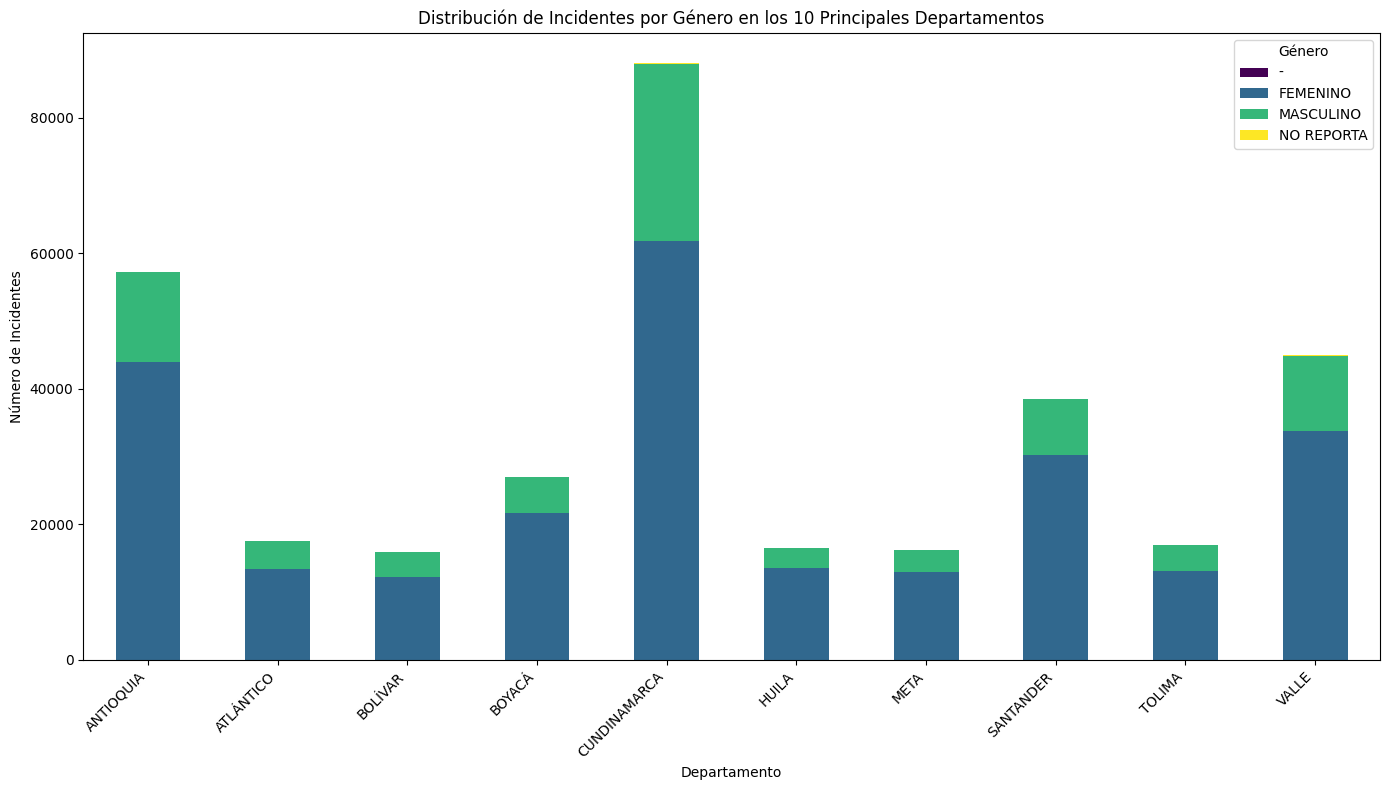

In [27]:
incidentes_departmento_genero.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis')
plt.title('Distribución de Incidentes por Género en los 10 Principales Departamentos')
plt.xlabel('Departamento')
plt.ylabel('Número de Incidentes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

3. Análisis de la Columna CANTIDAD

In [28]:
print("Estadísticas descriptivas de la columna 'CANTIDAD':")
display(df_clean['CANTIDAD'].describe())

Estadísticas descriptivas de la columna 'CANTIDAD':


,CANTIDAD
count,476959.000000
mean,1.707776
std,3.338684
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,130.000000


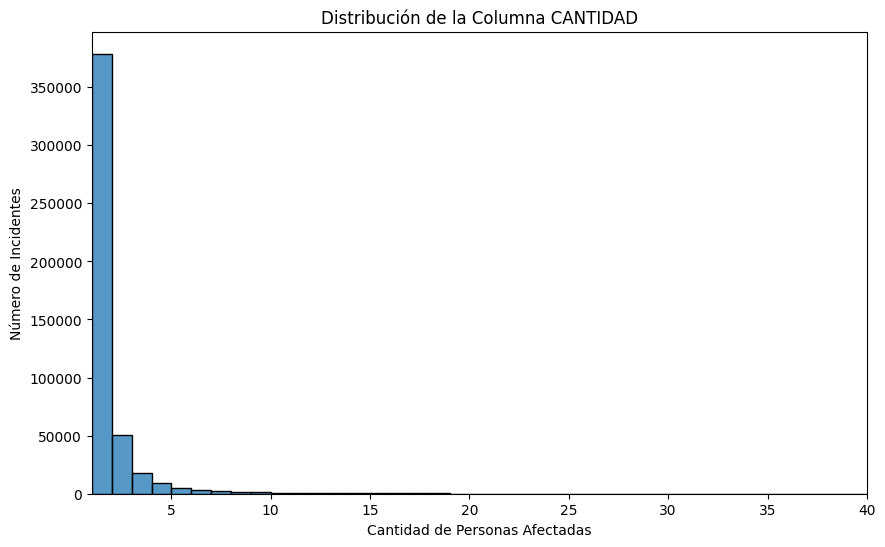

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['CANTIDAD'], bins=range(1, 42), kde=False)
plt.title('Distribución de la Columna CANTIDAD')
plt.xlabel('Cantidad de Personas Afectadas')
plt.ylabel('Número de Incidentes')
plt.xlim(1, 40)
plt.show()

In [30]:
print("Cantidad promedio de personas afectadas por Género:")
display(df_clean.groupby('GENERO')['CANTIDAD'].mean().sort_values(ascending=False))

print("\nCantidad promedio de personas afectadas por Grupo Etario:")
display(df_clean.groupby('GRUPO ETARIO')['CANTIDAD'].mean().sort_values(ascending=False))

print("\nCantidad promedio de personas afectadas por Armas/Medios:")
display(df_clean.groupby('ARMAS MEDIOS')['CANTIDAD'].mean().sort_values(ascending=False))

Cantidad promedio de personas afectadas por Género:


,CANTIDAD
GENERO,
FEMENINO,1.787637
MASCULINO,1.442519
-,1.142857
NO REPORTA,1.085034



Cantidad promedio de personas afectadas por Grupo Etario:


,CANTIDAD
GRUPO ETARIO,
ADULTOS,1.760833
Desconocido,1.565136
MENORES,1.434114
ADOLESCENTES,1.191506
NO REPORTA,1.091241



Cantidad promedio de personas afectadas por Armas/Medios:


,CANTIDAD
ARMAS MEDIOS,
NO REPORTADO,2.081131
SIN EMPLEO DE ARMAS,2.050958
ESCOPOLAMINA,1.888170
CONTUNDENTES,1.550373
ARMA BLANCA / CORTOPUNZANTE,1.172104
NO REPORTA,1.124632
ARMA DE FUEGO,1.038743
CORTANTES,1.035149
CORTOPUNZANTES,1.023993


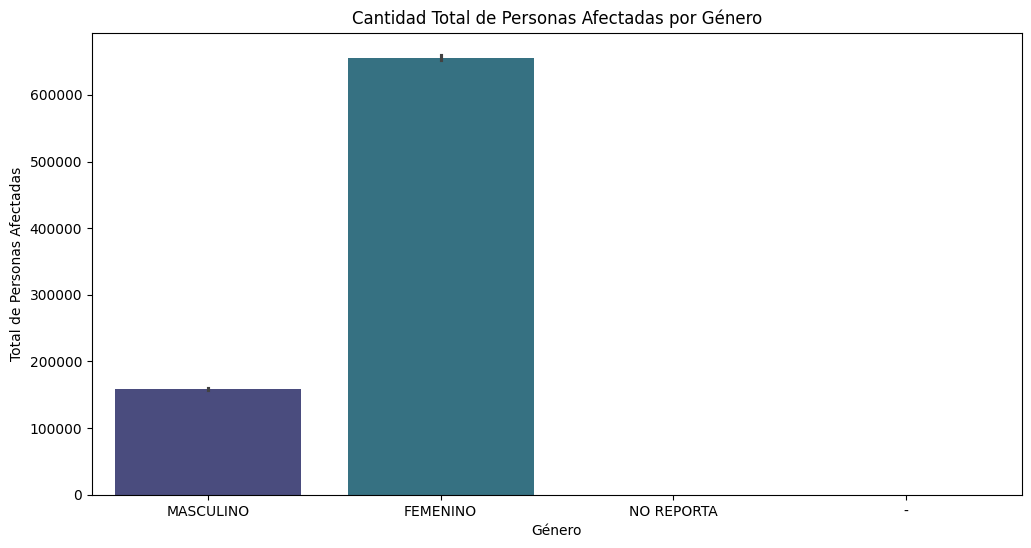

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_clean, x='GENERO', y='CANTIDAD', hue='GENERO', estimator=sum, palette='viridis', legend=False)
plt.title('Cantidad Total de Personas Afectadas por Género')
plt.xlabel('Género')
plt.ylabel('Total de Personas Afectadas')
plt.show()

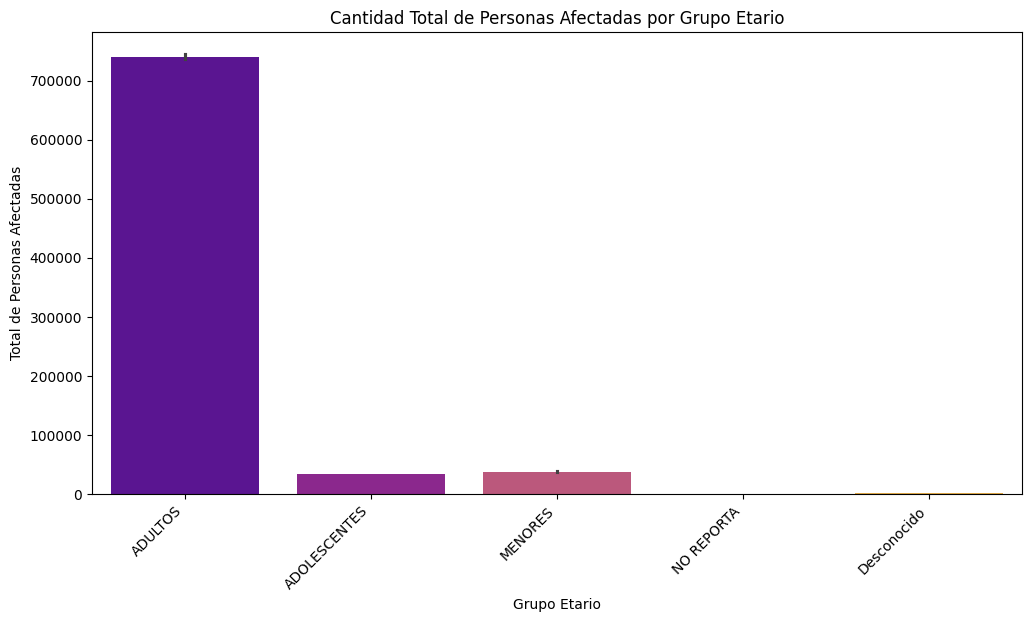

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_clean, x='GRUPO ETARIO', y='CANTIDAD', hue='GRUPO ETARIO', estimator=sum, palette='plasma', legend=False)
plt.title('Cantidad Total de Personas Afectadas por Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Total de Personas Afectadas')
plt.xticks(rotation=45, ha='right')
plt.show()

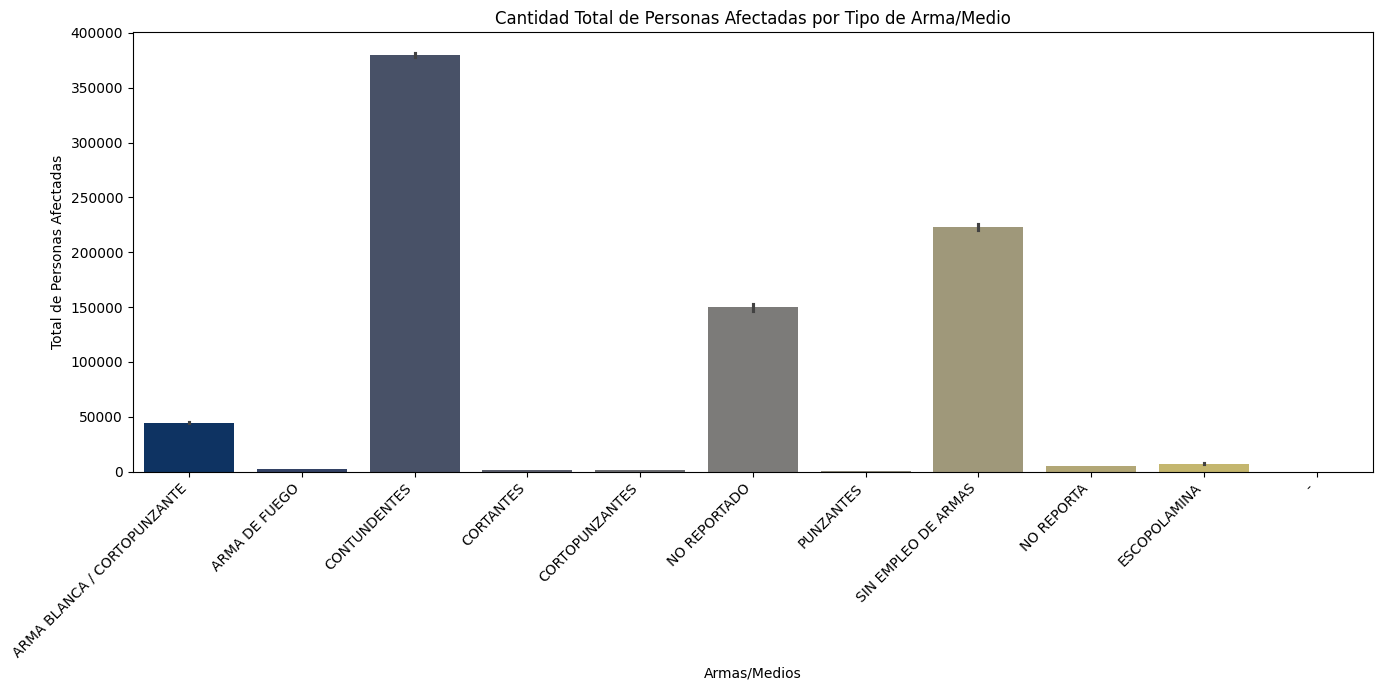

In [33]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df_clean, x='ARMAS MEDIOS', y='CANTIDAD', hue='ARMAS MEDIOS', estimator=sum, palette='cividis', legend=False)
plt.title('Cantidad Total de Personas Afectadas por Tipo de Arma/Medio')
plt.xlabel('Armas/Medios')
plt.ylabel('Total de Personas Afectadas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Resultados del Análisis de Violencia Intrafamiliar en Colombia entre 2010 al 2021

### 1. Resumen del Análisis

El objetivo de este análisis fue explorar y visualizar los patrones de incidentes de violencia intrafamiliar reportados, utilizando un conjunto de datos que incluye información sobre departamento, municipio, tipo de arma/medio, fecha, género, grupo etario y la cantidad de personas afectadas. Los datos analizados abarcan el periodo desde **2010 hasta 2021**.

El proceso se llevó a cabo en las siguientes fases:

*   **Extracción y Carga de Datos:** Se cargó el archivo CSV 'Reporte_Delito_Violencia_Intrafamiliar_Polic_a_Nacional.csv' en un DataFrame de Pandas.
*   **Transformación y Limpieza de Datos:**
    *   Se creó una copia del DataFrame original (`df_clean`).
    *   La columna 'FECHA HECHO' se convirtió al formato `datetime`, manejando errores de conversión. Se generaron las columnas 'YEAR' y 'MONTH' a partir de esta.
    *   Los valores nulos en 'GRUPO ETARIO' se imputaron con la cadena 'Desconocido'.
    *   Las filas con valores nulos restantes en 'FECHA HECHO', 'GENERO' y 'ARMAS MEDIOS' fueron eliminadas para asegurar la calidad del análisis.
*   **Análisis Exploratorio de Datos (EDA):** Se realizaron análisis de distribución para las principales columnas categóricas ('GENERO', 'GRUPO ETARIO', 'ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO') y se visualizaron utilizando gráficos de barras y de líneas para identificar tendencias temporales y patrones geográficos y demográficos.
*   **Análisis Específico de la Columna 'CANTIDAD':** Se examinó la distribución y las estadísticas descriptivas de la columna 'CANTIDAD' (número de personas afectadas por incidente) y se analizó su relación con 'GENERO', 'GRUPO ETARIO' y 'ARMAS MEDIOS', tanto en promedio como en totales.

### 2. Hallazgos Clave

**Periodo Analizado:** Los datos cubren incidentes registrados desde el año **2010 hasta el 2021**.

**2.1. Distribución Demográfica y de Género:**

*   **Dominio Femenino:** Las mujeres son, de manera abrumadora, las principales víctimas de violencia intrafamiliar en casi todos los grupos etarios y regiones. En el grupo de 'ADULTOS', el número de incidentes que afectan a mujeres supera significativamente al de hombres.
*   **Grupo Etario más Afectado:** El grupo de 'ADULTOS' registra la mayor cantidad de incidentes, seguido por 'ADOLESCENTES' y 'MENORES'.
*   **Patrón en Menores:** Sorprendentemente, en el grupo de 'MENORES', los hombres presentan un número ligeramente mayor de incidentes que las mujeres, lo que sugiere dinámicas específicas en la violencia infantil.

**2.2. Distribución Geográfica:**

*   **Departamentos de Alta Incidencia:** Cundinamarca, Antioquia y Valle son los departamentos con el mayor número total de incidentes reportados. Este patrón se mantiene consistente con la predominancia de víctimas femeninas en estas regiones.
*   **Consistencia Regional:** La desproporción de incidentes que afectan a mujeres es un patrón constante en los 10 departamentos con mayor número de casos, indicando un problema sistémico a nivel nacional.

**2.3. Tipos de Armas/Medios:**

*   Los incidentes de violencia intrafamiliar utilizan una variedad de medios, siendo 'CONTUNDENTES' y 'ARMA BLANCA / CORTOPUNZANTE' los más frecuentes, seguidos por 'OTRO'.

**2.4. Tendencias Temporales:**

*   La tendencia de incidentes ha mostrado fluctuaciones anuales, con un pico notable en 2020. Es importante considerar factores externos (ej. pandemia COVID-19) que pudieron influir en este aumento.

**2.5. Análisis de la Columna 'CANTIDAD' (Personas Afectadas):**

*   **Mayormente Unipersonal:** La gran mayoría de los incidentes reportados involucran a una sola persona ('CANTIDAD' = 1), lo que sugiere que la violencia intrafamiliar se reporta predominantemente como eventos individuales.
*   **Promedio por Género/Grupo:** El promedio de personas afectadas por incidente no varía drásticamente entre géneros o grupos etarios, manteniéndose cerca de 1, lo que refuerza la idea de que los reportes suelen ser por víctima individual.
*   **Total de Afectados:** Al sumar la columna `CANTIDAD`, se confirma que el género femenino y el grupo etario 'ADULTOS' son los que acumulan el mayor número total de personas afectadas, reflejando tanto la alta frecuencia de incidentes como el impacto predominante en estos grupos.

### 3. Conclusiones Generales

Los datos revelan que la violencia intrafamiliar es un problema persistente y generalizado en Colombia, afectando de manera desproporcionada a las mujeres adultas. Si bien los hombres también son víctimas, especialmente los menores, la magnitud del problema en la población femenina es alarmante. Los patrones son consistentes en las principales regiones del país y a lo largo del tiempo, con un aumento significativo en años recientes. El análisis de la `CANTIDAD` de personas afectadas subraya que la mayoría de los reportes se centran en víctimas individuales, aunque el impacto acumulado es inmenso para las poblaciones más vulnerables.

### 4. Recomendaciones

1.  **Intervenciones Dirigidas:** Desarrollar y fortalecer programas de prevención y apoyo específicamente dirigidos a mujeres adultas, dado su alto grado de victimización.
2.  **Investigación en Menores:** Realizar investigaciones cualitativas y cuantitativas más profundas sobre las causas y dinámicas de la violencia intrafamiliar en menores, especialmente el patrón observado en los varones, para diseñar estrategias de prevención y apoyo adecuadas.
3.  **Concientización y Educación:** Implementar campañas de concientización pública que aborden las diferentes manifestaciones de la violencia intrafamiliar y fomenten la denuncia, haciendo hincapié en la importancia de reportar todos los casos, incluso aquellos que no resultan en lesiones graves.
4.  **Análisis de Factores Contextuales:** Integrar el análisis de datos con información sobre factores socioeconómicos, culturales y coyunturales (ej. efectos de la pandemia) para obtener una comprensión más holística del problema.
5.  **Desglose de Tipos de Violencia:** Si los datos lo permiten, desglosar los incidentes por tipo de violencia (física, psicológica, económica, etc.) para identificar patrones más específicos y diseñar respuestas más segmentadas.
6.  **Monitoreo Continuo:** Mantener un seguimiento constante de las tendencias temporales y geográficas para evaluar la efectividad de las políticas y programas implementados.
